# Part 1 - Logistic Regression - Using Scikit-learn library 

This notebook implements logistic regression - Part 1, by using the scikit-learn library calling `LogisticRegression().fit()`.

Implementation is as Follows:
1. Load the Titanic Dataset and Data Exploration including Visualization
2. Data Transformation - Splitting the Data in Train, Test
3. Model Training - Using Logistic Regression classification model by scikit-learn.
4. Model Performace Evaluation - Exploration and usage of multiple evaluation metrics.

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Data Exploration

In [3]:
data = pd.read_csv("data/titanic.csv")
print("Data shape (rows, cols):", data.shape)
print("Columns in the dataset:", data.columns.tolist())
data.head()

Data shape (rows, cols): (887, 8)
Columns in the dataset: ['sex', 'age', 'family_size', 'fare', '1st_class', '2nd_class', '3rd_class', 'survived']


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


### 1.1 Data Types and Non-Null count info and Some statistical info about the dataset

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB


In [5]:
data.describe()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


### 1.2 Visualization about the data and Exploration of relation between surviver and other factors

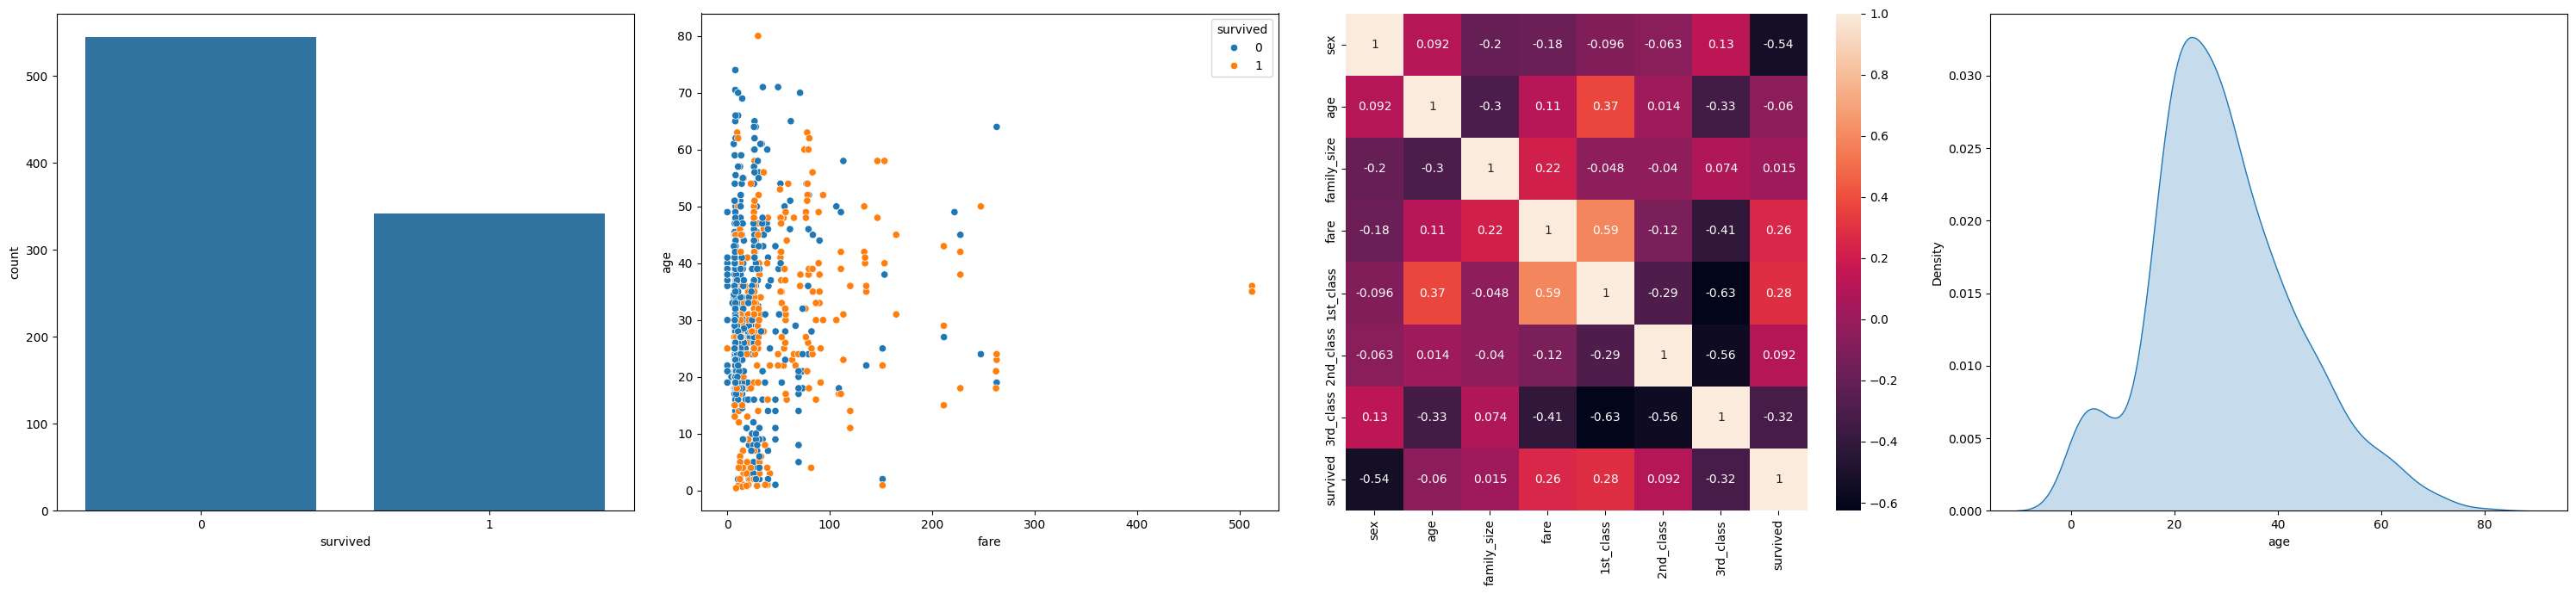

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(30, 7))

# Number of survivors vs non-survivors
# We can clearly see that it is Binomial Logistic regression problem
sns.countplot(x="survived", data=data, ax=axes[0])

# Relation between fare and age, colored by survival
sns.scatterplot(x="fare", y="age", hue="survived", data=data, ax=axes[1])

# Correlation heatmap of numerical features
sns.heatmap(data.corr(), annot=True, ax=axes[2])

# Distribution of ages
sns.kdeplot(x="age", data=data, fill=True, ax=axes[3])

plt.tight_layout()
plt.show()

# 2 - Data Processing - Split of data for Train, Test

In [7]:
FEATURES = ["sex", "age", "family_size", "fare", "1st_class", "2nd_class", "3rd_class"]
TARGET = "survived"

features = data[FEATURES]
target = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


# 3 - Model Training

In [24]:
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=0)
logistic_regression_model.fit(X_train, y_train)

y_pred = logistic_regression_model.predict(X_test)

# 4 - Model Evaluation

In [25]:
# Evaluate the model, using the scikit-learn built-in accuracy_score function
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy on test set: {accuracy:.4f}")

Model accuracy on test set: 0.7303


In [26]:
logistic_regression_model.coef_[0]

array([-2.7609016 , -0.03584133, -0.30302564,  0.00510109,  0.91346578,
        0.1557405 , -1.07152844])

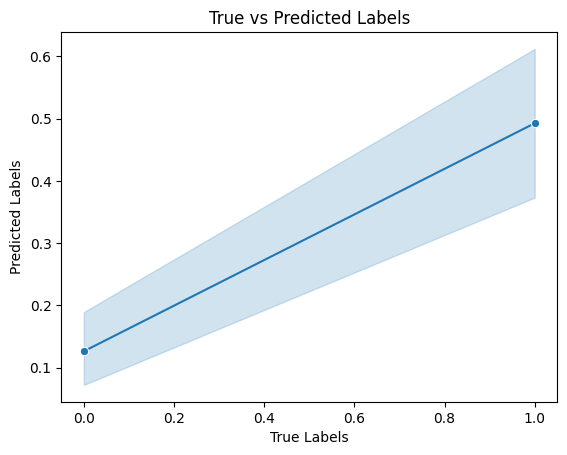

In [27]:
sns.lineplot(x=y_test.to_list(), y=y_pred.tolist(), marker="o")
plt.xlabel("True Labels")
plt.ylabel("Predicted Labels")
plt.title("True vs Predicted Labels")
plt.show()

# Make data Normalization

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)
scaled_X_train

array([[ 0.76327537, -0.44900956, -0.5539584 , ..., -0.56160385,
         1.97222087, -1.11838886],
       [ 0.76327537, -0.09415348,  0.64529811, ..., -0.56160385,
        -0.5070426 ,  0.89414338],
       [-1.31014316, -1.93940511,  3.04381112, ..., -0.56160385,
        -0.5070426 ,  0.89414338],
       ...,
       [ 0.76327537, -0.37803835, -0.5539584 , ..., -0.56160385,
         1.97222087, -1.11838886],
       [ 0.76327537,  2.46081032,  2.44418286, ...,  1.78061457,
        -0.5070426 , -1.11838886],
       [ 0.76327537,  0.2607026 , -0.5539584 , ..., -0.56160385,
        -0.5070426 ,  0.89414338]], shape=(709, 7))

In [30]:
reg_model = LogisticRegression(max_iter=1000, random_state=0)
reg_model.fit(scaled_X_train, y_train)
y_pred_scaled = reg_model.predict(scaled_X_test)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Model accuracy on test set after scaling: {accuracy_scaled:.4f}")

Model accuracy on test set after scaling: 0.7416


In [34]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
mm_X_train = minmax_scaler.fit_transform(X_train)
mm_X_test = minmax_scaler.transform(X_test)
mm_X_train

array([[1.        , 0.28148242, 0.        , ..., 0.        , 1.        ,
        0.        ],
       [1.        , 0.34451027, 0.2       , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.01676541, 0.6       , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [1.        , 0.29408799, 0.        , ..., 0.        , 1.        ,
        0.        ],
       [1.        , 0.79831085, 0.5       , ..., 1.        , 0.        ,
        0.        ],
       [1.        , 0.40753813, 0.        , ..., 0.        , 0.        ,
        1.        ]], shape=(709, 7))

In [35]:
reg_model = LogisticRegression(max_iter=1000, random_state=0)
reg_model.fit(mm_X_train, y_train)
y_pred_mm = reg_model.predict(mm_X_test)
accuracy_mm = accuracy_score(y_test, y_pred_mm)
print(f"Model accuracy on test set after MinMax scaling: {accuracy_mm:.4f}")

Model accuracy on test set after MinMax scaling: 0.7472


## Summary

We implemented logistic regression using scikit-learn. 
Key takeaways:

- We have binomial logistic promblem at hand with Titanic Dataset.
- **Feature standardization** is critical for gradient descent to converge
  efficiently - without it, features on very different scales (e.g., Age vs.
  Fare) cause the loss surface to be poorly conditioned. 
- Evaluation Looks like:
  - Without any normalization: 0.7303
  - With StandardScalar: 0.7416
  - With MinMaxScalar: 0.7472
- After doing data normalizastion, we see a little bit improvement on different data normalization technique.